In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## Load Data

In [2]:
try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# load f6
function_folder = os.path.join(base_dir, "function_6")
inputs = np.load(os.path.join(function_folder, "initial_inputs.npy"))
outputs = np.load(os.path.join(function_folder, "initial_outputs.npy"))

# reshape if needed
if inputs.ndim == 1:
    inputs = inputs.reshape(-1, 1)
if outputs.ndim == 1:
    outputs = outputs.reshape(-1, 1)

# create dataframe
input_cols = [f"X{j+1}" for j in range(inputs.shape[1])]
output_cols = [f"y{j+1}" for j in range(outputs.shape[1])]

df_f6 = pd.DataFrame(
    np.concatenate([inputs, outputs], axis=1),
    columns=input_cols + output_cols
)

print(f"Loaded function 6: shape = {df_f6.shape}, columns = {df_f6.columns.tolist()}")



Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']


In [3]:
week1_results = {"f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064)}

In [4]:
week2_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203)}

In [5]:
week3_results = {"f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669)}

In [6]:
week4_results = {"f6": ([0.494472, 0.050000, 0.451934, 0.152883, 0.386469], -1.421729209627387)}

In [7]:
week5_results = {"f6": ([0.666300, 0.229100, 0.516000, 0.789473, 0.315789], -0.7791148650103992)}

In [8]:
week6_results = {"f6": ([0.537637, 0.403865, 0.951610, 0.943059, 0.050967], -0.6814591029200937)}

In [9]:
week7_results = {"f6": ([0.212341, 0.007631, 0.955851, 0.999487, 0.763435], -1.8381389462062772)}

In [10]:
week8_results = {"f6": ([0.987971, 0.066922, 0.908036, 0.000615, 0.964637], -2.7568441153569343)}

In [11]:
week9_results = {"f6": ([0.553475, 0.343241, 0.535219, 0.771873, 0.140689], -0.24936021594704408)}

In [12]:
week10_results = {"f6": ([0.500199, 0.440981, 0.607396, 0.749856, 0.063960], -0.2244249365413683)}

In [13]:
week11_results = {"f6": ([0.548528, 0.190888, 0.279484, 0.804716, 0.020038], -0.7678682303650092)}

In [14]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results,
    "week4": week4_results,
    "week5": week5_results,
    "week6": week6_results,
    "week7": week7_results,
    "week8": week8_results,
    "week9": week9_results,
    "week10": week10_results,
    "week11": week11_results,
}

output_col = output_cols[0]   # this gives "y1"

# add weekly results to df_f6

for week, results in weekly_results.items():
    
    if "f6" not in results:
        continue
    
    inputs, output = results["f6"]
    
    # convert to numpy arrays
    inputs = np.array(inputs).reshape(1, -1)
    output = np.array([output]).reshape(1, -1)
    
    # build dataframe row with the same columns as df_f6
    df_new_row = pd.DataFrame(
        np.concatenate([inputs, output], axis=1),
        columns=["X1", "X2", "X3", "X4", "X5", "y1"]
    )
    
    # append to df_f5
    df_f6 = pd.concat([df_f6, df_new_row], ignore_index=True)
    
    # remove duplicates
    df_f6 = df_f6.drop_duplicates(ignore_index=True)

print("updated f6 shape:", df_f6.shape)


updated f6 shape: (31, 6)


In [15]:
print(df_f6)

          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820  0.109476  0.877888 -2

In [16]:
display(df_f6.describe().T)  

,count,mean,std,min,25%,50%,75%,max
X1,31.0,0.545245,0.266779,0.021735,0.390026,0.548528,0.743558,0.987971
X2,31.0,0.434774,0.299525,0.001300,0.229100,0.343241,0.731862,0.931871
X3,31.0,0.526831,0.301744,0.016523,0.343461,0.516000,0.771980,0.978806
X4,31.0,0.598182,0.305648,0.000615,0.372389,0.693997,0.813066,1.000000
X5,31.0,0.371564,0.307572,0.000000,0.090971,0.315789,0.606489,0.964637
y1,31.0,-1.311157,0.622261,-2.756844,-1.698451,-1.294247,-0.773492,-0.224425


## Feature vs y scatter plots

Feature vs y1 for f6 with conditional region visualisation


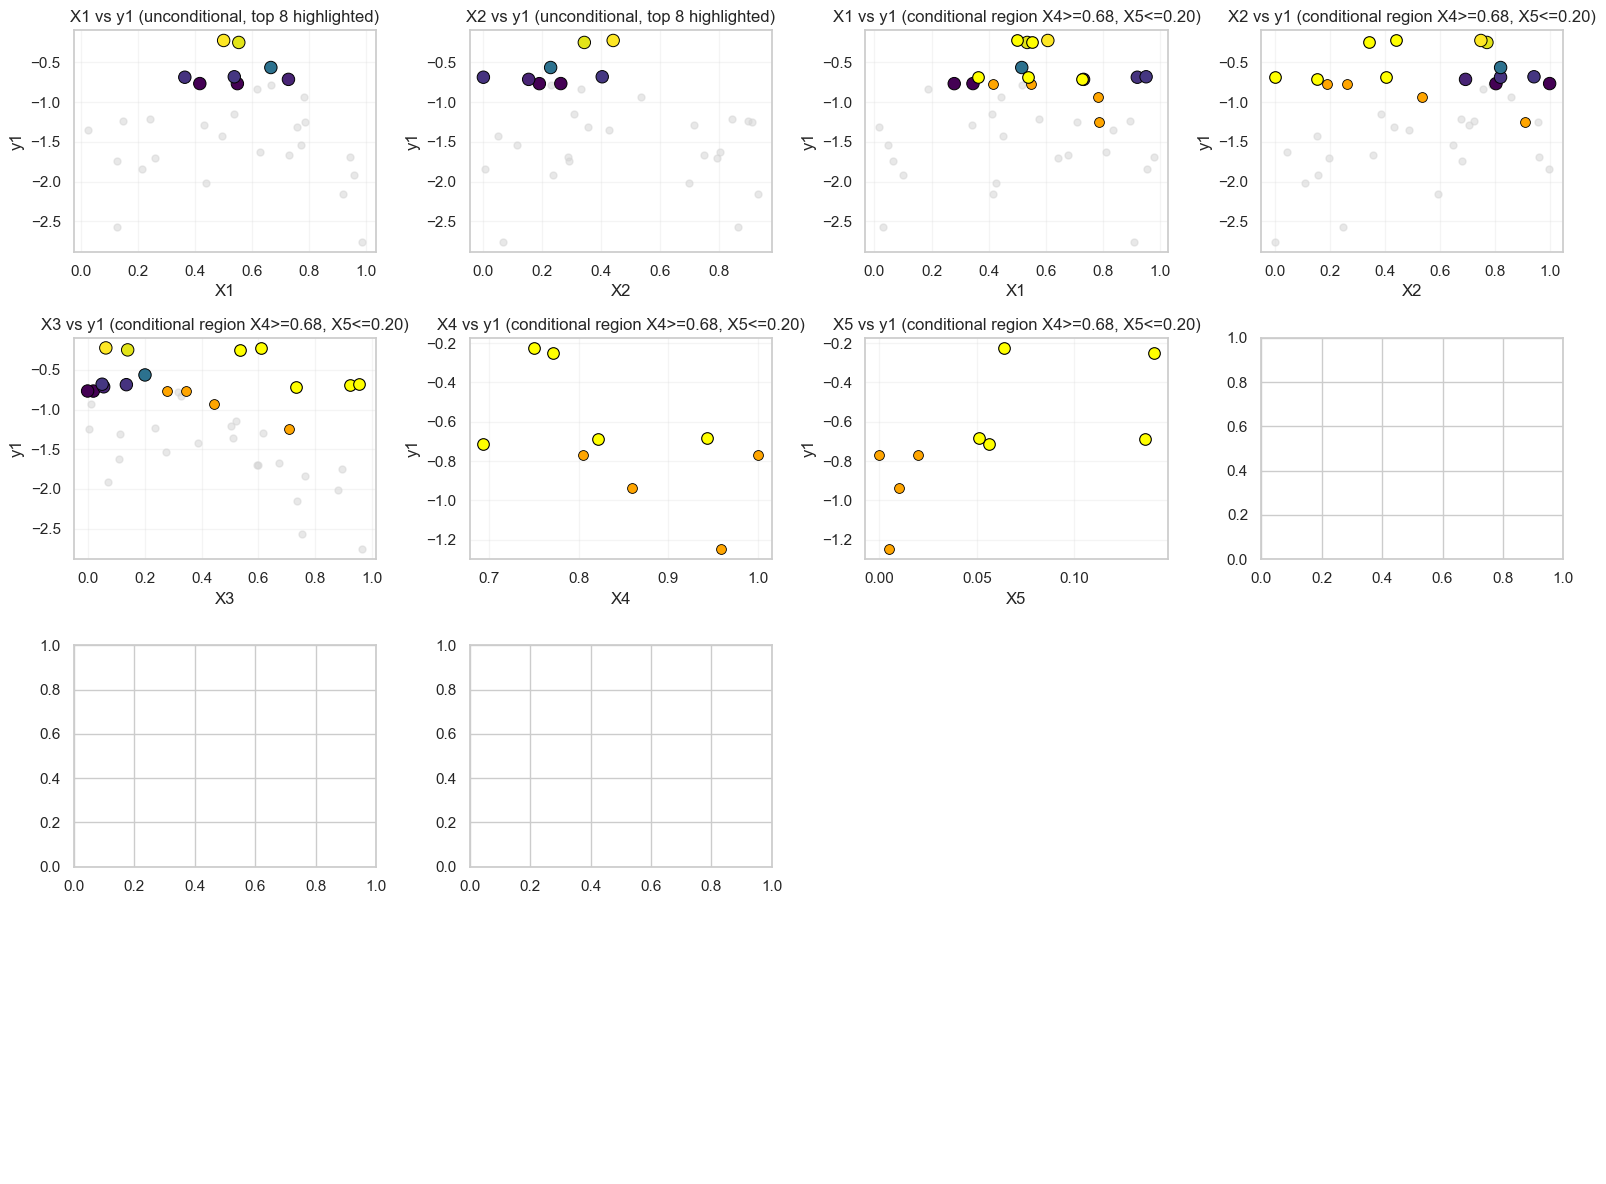

In [17]:
print("Feature vs y1 for f6 with conditional region visualisation")

# extract inputs and output for f6
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# identify top 8 globally
top8_idx = np.argsort(y_f6)[-8:]
y_top8 = y_f6[top8_idx]
X_top8 = X_f6[top8_idx]

# conditional region mask
mask_cond = (df_f6["X4"] >= 0.68) & (df_f6["X5"] <= 0.20)
X_cond = X_f6[mask_cond]
y_cond = y_f6[mask_cond]

# rank within conditional region
order_cond = np.argsort(y_cond)
top5_idx = order_cond[-5:]
next5_idx = order_cond[-10:-5]
rest_idx = order_cond[:-10]

# number of features
n_features = X_f6.shape[1]
ncols = 4
nrows = 2 * int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))

axes = axes.ravel().tolist()

# unconditional row
for j, col in enumerate(input_cols_f6):
    ax = axes[j]

    ax.scatter(
        X_f6[:, j],
        y_f6,
        c="lightgray",
        s=25,
        alpha=0.5
    )

    sc = ax.scatter(
        X_top8[:, j],
        y_top8,
        c=y_top8,
        cmap="viridis",
        s=80,
        edgecolor="black",
        linewidth=0.7
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (unconditional, top 8 highlighted)")
    ax.grid(alpha=0.2)

# conditional row
offset = int(np.ceil(n_features / ncols))

for j, col in enumerate(input_cols_f6):
    ax = axes[offset + j]

    ax.scatter(
        X_cond[rest_idx, j],
        y_cond[rest_idx],
        c="grey",
        s=30,
        alpha=0.6
    )

    ax.scatter(
        X_cond[next5_idx, j],
        y_cond[next5_idx],
        c="orange",
        s=50,
        edgecolor="black",
        linewidth=0.6
    )

    ax.scatter(
        X_cond[top5_idx, j],
        y_cond[top5_idx],
        c="yellow",
        s=70,
        edgecolor="black",
        linewidth=0.8
    )

    ax.set_xlabel(col)
    ax.set_ylabel("y1")
    ax.set_title(f"{col} vs y1 (conditional region X4>=0.68, X5<=0.20)")
    ax.grid(alpha=0.2)

# hide unused axes
for k in range(n_features * 2, len(axes)):
    axes[k].axis("off")

plt.tight_layout()
plt.show()


## Distribution Analysis

f6 – feature and output distributions


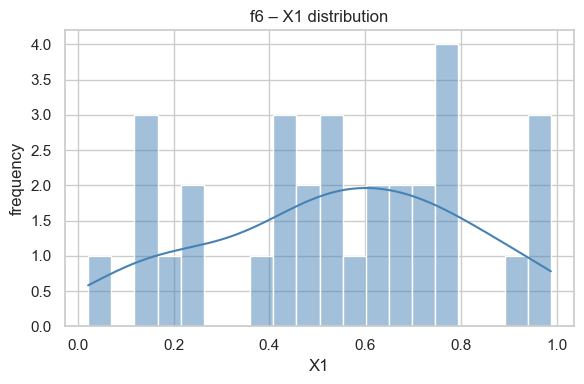

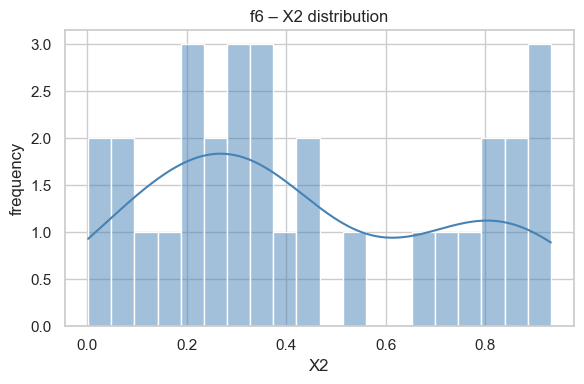

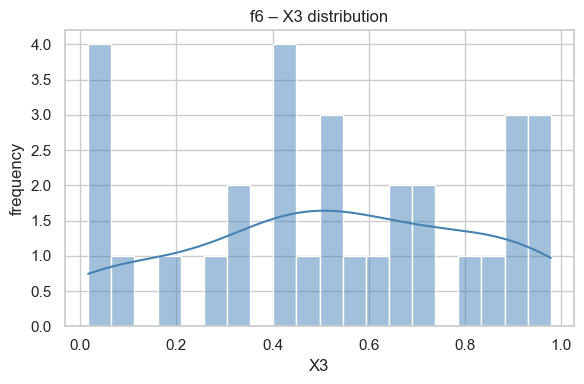

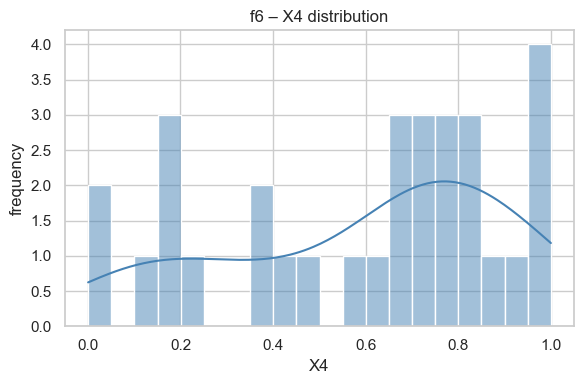

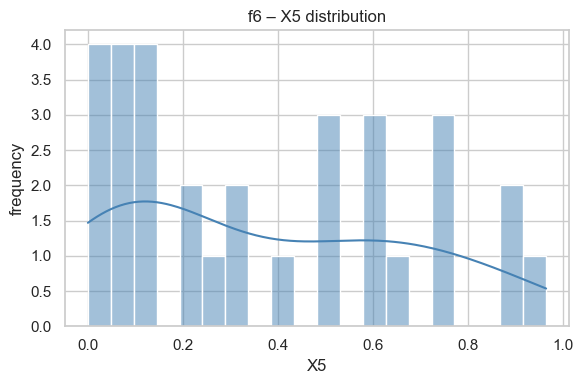

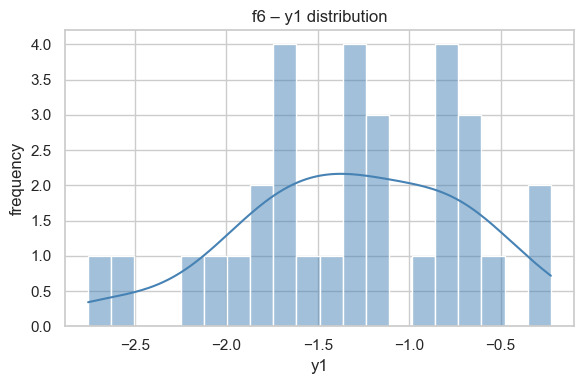

In [18]:
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
output_col_f6 = [c for c in df_f6.columns if c.startswith("y")][0]

print("f6 – feature and output distributions")

all_cols_raw_f6 = input_cols_f6 + [output_col_f6]

for col in all_cols_raw_f6:
    plt.figure(figsize=(6, 4))

    sns.histplot(
        df_f6[col],
        kde=True,
        bins=20,
        color="steelblue"
    )

    plt.title(f"f6 – {col} distribution")
    plt.xlabel(col)
    plt.ylabel("frequency")

    plt.tight_layout()
    plt.show()



## Y vs Instance Index

f6 – y vs instance index


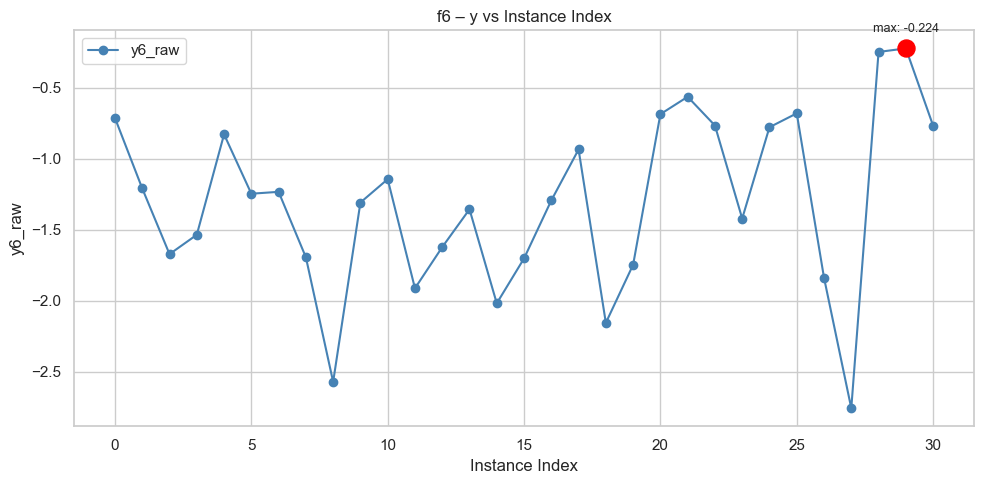

In [19]:
print("f6 – y vs instance index")

# clean copy of raw data
df_f6_plot = df_f6.copy()

# extract raw y
y_raw = df_f6_plot[output_col_f6].values
x = np.arange(len(y_raw))

plt.figure(figsize=(10, 5))

plt.plot(x, y_raw, marker="o", linestyle="-", color="steelblue", label="y6_raw")

# highlight maximum
max_idx = np.argmax(y_raw)
max_val = y_raw[max_idx]

plt.scatter(max_idx, max_val, s=150, color="red", zorder=5)
plt.annotate(
    f"max: {max_val:.3f}",
    (max_idx, max_val),
    textcoords="offset points",
    xytext=(0, 12),
    ha="center",
    fontsize=9
)

plt.title("f6 – y vs Instance Index")
plt.xlabel("Instance Index")
plt.ylabel("y6_raw")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## Pearson Correlation

f6 Pearson Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.171996,-0.048757,-0.060889,-0.222793,-0.057653
X2,-0.171996,1.000000,0.000903,-0.177414,0.150022,-0.243347
X3,-0.048757,0.000903,1.000000,0.176243,0.011028,0.093576
X4,-0.060889,-0.177414,0.176243,1.000000,-0.396964,0.620060
X5,-0.222793,0.150022,0.011028,-0.396964,1.000000,-0.741068
y1,-0.057653,-0.243347,0.093576,0.620060,-0.741068,1.000000


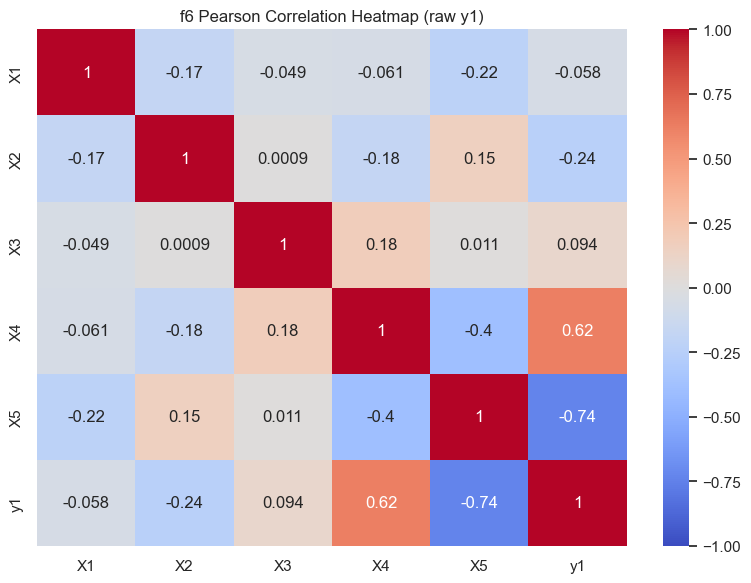

In [20]:
df_raw = df_f6.copy()

print("f6 Pearson Correlation Matrix (raw y1)")

corr_raw = df_raw.corr()
display(corr_raw)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Pearson Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()

## Spearman Correlation

f6 Spearman Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.124420,-0.028836,-0.016332,-0.236516,-0.065732
X2,-0.124420,1.000000,-0.047389,-0.188930,0.060692,-0.182276
X3,-0.028836,-0.047389,1.000000,0.242968,-0.001008,0.115334
X4,-0.016332,-0.188930,0.242968,1.000000,-0.449194,0.589113
X5,-0.236516,0.060692,-0.001008,-0.449194,1.000000,-0.701210
y1,-0.065732,-0.182276,0.115334,0.589113,-0.701210,1.000000


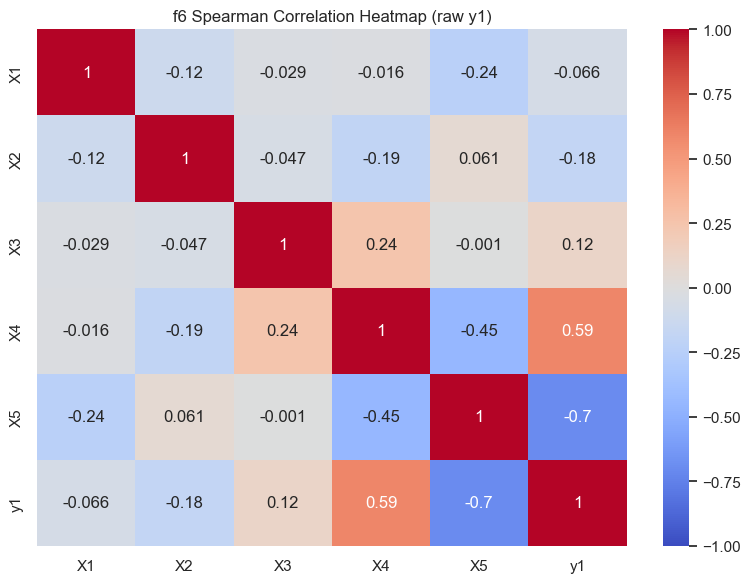

In [21]:
# spearman correlation with raw y1
df_raw = df_f6.copy()

print("f6 Spearman Correlation Matrix (raw y1)")

corr_raw_spearman = df_raw.corr(method="spearman")
display(corr_raw_spearman)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_spearman,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 Spearman Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Kendall Correlation

f6 Kendall Correlation Matrix (raw y1)


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.112069,-0.021552,0.004306,-0.180840,-0.055974
X2,-0.112069,1.000000,-0.021552,-0.133477,0.025834,-0.133477
X3,-0.021552,-0.021552,1.000000,0.163617,-0.004306,0.094726
X4,0.004306,-0.133477,0.163617,1.000000,-0.359140,0.432258
X5,-0.180840,0.025834,-0.004306,-0.359140,1.000000,-0.505376
y1,-0.055974,-0.133477,0.094726,0.432258,-0.505376,1.000000


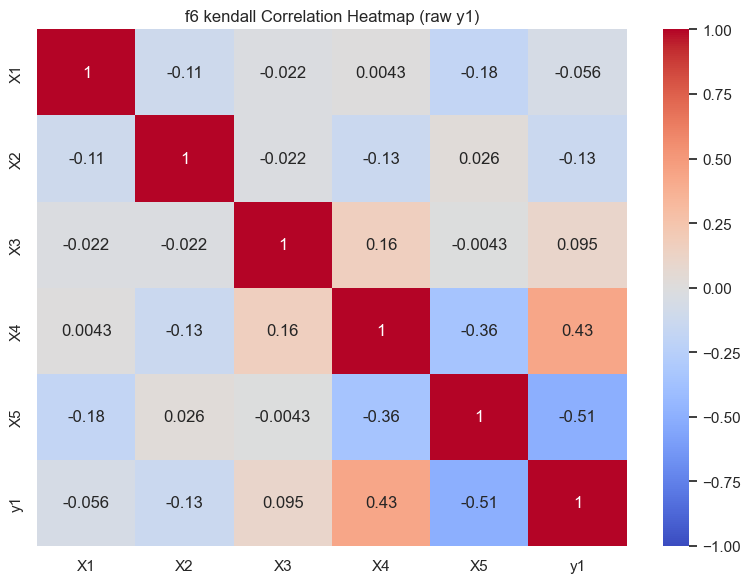

In [22]:
# Kendall correlation with raw y1
df_raw = df_f6.copy()

print("f6 Kendall Correlation Matrix (raw y1)")

corr_raw_kendall = df_raw.corr(method="kendall")
display(corr_raw_kendall)

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_raw_kendall,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("f6 kendall Correlation Heatmap (raw y1)")
plt.tight_layout()
plt.show()


## Mutual Information

In [23]:
from sklearn.feature_selection import mutual_info_regression

print("f6 — Mutual Information with Output")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

X_f6 = df_f6_raw[input_cols_f6].values
y_f6 = df_f6_raw[output_col_f6].values

# compute mutual information
mi_f6 = mutual_info_regression(X_f6, y_f6, random_state=42)

# build dataframe
mi_f6_df = pd.DataFrame({
    "Feature": input_cols_f6,
    "Mutual_Info": mi_f6
}).sort_values(by="Mutual_Info", ascending=False)

display(mi_f6_df)


f6 — Mutual Information with Output


,Feature,Mutual_Info
4,X5,0.412650
3,X4,0.179517
1,X2,0.034300
0,X1,0.003239
2,X3,0.000000


## Partial Correlation

In [24]:
!pip install pingouin
import pingouin as pg

print("f6 (Raw y1) — Partial Correlation")

df_f6_raw = df_f6.copy()

# define inputs and output
input_cols_f6 = [c for c in df_f6_raw.columns if c.startswith("X")]
output_col_f6 = "y1"

# compute partial correlations for each X feature
for x in input_cols_f6:
    covars = [c for c in input_cols_f6 if c != x]  # all other X's as covariates
    
    pcorr_raw_f6 = pg.partial_corr(
        data=df_f6_raw,
        x=x,
        y=output_col_f6,
        covar=covars
    )
    
    print(f"\nPartial correlation for {x}:")
    display(pcorr_raw_f6)


f6 (Raw y1) — Partial Correlation

Partial correlation for X1:


,n,r,CI95%,p-val
pearson,31,-0.336276,"[-0.64, 0.05]",0.086343



Partial correlation for X2:


,n,r,CI95%,p-val
pearson,31,-0.220819,"[-0.55, 0.17]",0.268359



Partial correlation for X3:


,n,r,CI95%,p-val
pearson,31,0.061672,"[-0.33, 0.43]",0.75992



Partial correlation for X4:


,n,r,CI95%,p-val
pearson,31,0.476359,"[0.12, 0.73]",0.012008



Partial correlation for X5:


,n,r,CI95%,p-val
pearson,31,-0.7275,"[-0.87, -0.48]",0.000017


## XGBoost Feature Importance 

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- XGBoost provides a non‑linear, tree‑based feature‑importance ranking that independently validates the ARD length‑scale findings for f6, increasing confidence in the identified active dimensions.

  feature      gain    weight     cover
0      X1  0.082958  0.193925  0.198510
1      X2  0.047959  0.197430  0.182639
2      X3  0.048213  0.211449  0.197285
3      X4  0.353775  0.198598  0.219005
4      X5  0.467094  0.198598  0.202562


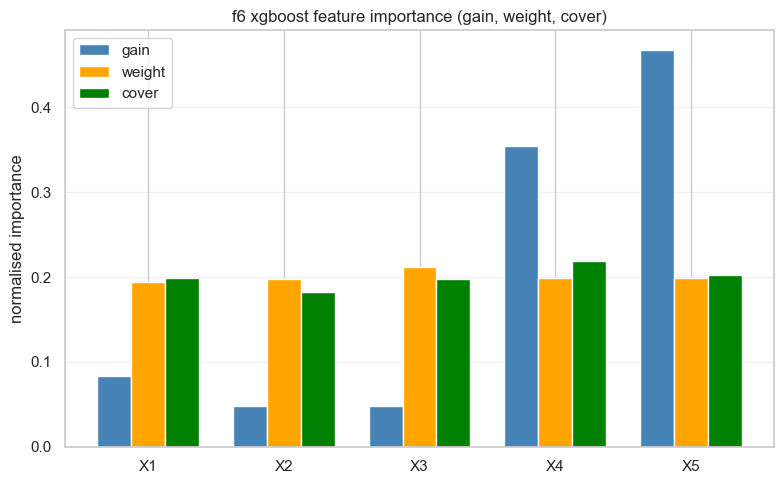

In [25]:
import xgboost as xgb

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# model configuration suitable for n=30
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=1
)

model.fit(X_f6, y_f6)

# gain-based importance (default)
importance_gain = model.feature_importances_

# weight and cover from booster
booster = model.get_booster()
importance_weight_raw = booster.get_score(importance_type="weight")
importance_cover_raw  = booster.get_score(importance_type="cover")
importance_gain_raw   = booster.get_score(importance_type="gain")

# align all three metrics to the feature order
importance_weight = np.array([importance_weight_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_cover  = np.array([importance_cover_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])
importance_gain2  = np.array([importance_gain_raw.get(f"f{i}", 0.0) for i in range(len(input_cols_f6))])

# normalise for comparability
def normalise(v):
    s = v.sum()
    return v / s if s > 0 else v

imp_gain_norm   = normalise(importance_gain)
imp_weight_norm = normalise(importance_weight)
imp_cover_norm  = normalise(importance_cover)

# assemble dataframe
df_imp = pd.DataFrame({
    "feature": input_cols_f6,
    "gain": imp_gain_norm,
    "weight": imp_weight_norm,
    "cover": imp_cover_norm
})

print(df_imp)

# plot
plt.figure(figsize=(8, 5))
width = 0.25
x = np.arange(len(input_cols_f6))

plt.bar(x - width, imp_gain_norm,   width=width, label="gain",   color="steelblue")
plt.bar(x,         imp_weight_norm, width=width, label="weight", color="orange")
plt.bar(x + width, imp_cover_norm,  width=width, label="cover",  color="green")

plt.xticks(x, input_cols_f6)
plt.ylabel("normalised importance")
plt.title("f6 xgboost feature importance (gain, weight, cover)")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## fANOVA implementation

**Reference:** Wang, Z., Eriksson, D. and Gardner, J. (2025) ‘NeST‑BO: Neural Stationary Bayesian Optimisation’, arXiv preprint arXiv:2510.05516.

- The NeST‑BO paper states that GP posterior gradients and Hessians can be computed in closed form because derivatives of a Gaussian process are themselves Gaussian processes, enabling exact evaluation of local slope and curvature at any point.

In [26]:
from sklearn.ensemble import RandomForestRegressor

# extract inputs and output
input_cols_f6 = [c for c in df_f6.columns if c.startswith("X")]
X_f6 = df_f6[input_cols_f6].values
y_f6 = df_f6["y1"].values

# random forest for fanova
rf = RandomForestRegressor(
    n_estimators=1000,
    max_features=None,
    min_samples_leaf=1,
    max_depth=None,
    random_state=42,
    n_jobs=1
)

rf.fit(X_f6, y_f6)

# grid for marginalisation
n_grid = 20
x4_grid = np.linspace(0, 1, n_grid)
x5_grid = np.linspace(0, 1, n_grid)

# means of inactive dims
x1_mean = np.mean(X_f6[:, 0])
x2_mean = np.mean(X_f6[:, 1])
x3_mean = np.mean(X_f6[:, 2])
x4_mean = np.mean(X_f6[:, 3])
x5_mean = np.mean(X_f6[:, 4])

# marginal effect of x4
grid_x4 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    x4_grid,
    np.full(n_grid, x5_mean)
])
marginal_x4 = rf.predict(grid_x4)

# marginal effect of x5
grid_x5 = np.column_stack([
    np.full(n_grid, x1_mean),
    np.full(n_grid, x2_mean),
    np.full(n_grid, x3_mean),
    np.full(n_grid, x4_mean),
    x5_grid
])
marginal_x5 = rf.predict(grid_x5)

# joint effect of x4 and x5
X4, X5 = np.meshgrid(x4_grid, x5_grid)
grid_joint = np.column_stack([
    np.full(n_grid*n_grid, x1_mean),
    np.full(n_grid*n_grid, x2_mean),
    np.full(n_grid*n_grid, x3_mean),
    X4.ravel(),
    X5.ravel()
])
joint_pred = rf.predict(grid_joint).reshape(n_grid, n_grid)

# interaction term
grand_mean = np.mean(rf.predict(X_f6))
interaction = joint_pred - marginal_x4[np.newaxis, :] - marginal_x5[:, np.newaxis] + grand_mean

# variance fractions
var_x4 = np.var(marginal_x4)
var_x5 = np.var(marginal_x5)
var_inter = np.var(interaction)
var_total = var_x4 + var_x5 + var_inter

print(f"x4 main effect fraction:    {var_x4/var_total:.3f}")
print(f"x5 main effect fraction:    {var_x5/var_total:.3f}")
print(f"x4*x5 interaction fraction: {var_inter/var_total:.3f}")


x4 main effect fraction:    0.541
x5 main effect fraction:    0.398
x4*x5 interaction fraction: 0.061


#### f6 | Anchored ARD-GP Final Exploitation with Tightened Trust Region, X3-Bounded EI, and GP Mean Comparison Gate

In [27]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

In [28]:
# Separate inputs (X) and outputs (y)
X_train_6 = df_f6[[c for c in df_f6.columns if c.startswith("X")]].values
y_train_6 = df_f6["y1"].values
print(X_train_6)
print(y_train_6)

[[7.28186105e-01 1.54692570e-01 7.32551669e-01 6.93996509e-01
  5.64013105e-02]
 [2.42384347e-01 8.44099972e-01 5.77809099e-01 6.79021284e-01
  5.01952888e-01]
 [7.29522610e-01 7.48106200e-01 6.79774641e-01 3.56552279e-01
  6.71053683e-01]
 [7.70620242e-01 1.14403744e-01 4.67799319e-02 6.48324285e-01
  2.73549053e-01]
 [6.18812299e-01 3.31802137e-01 1.87287868e-01 7.56238474e-01
  3.28834798e-01]
 [7.84958094e-01 9.10682349e-01 7.08120104e-01 9.59225429e-01
  4.91149586e-03]
 [1.45110786e-01 8.96684598e-01 8.96322235e-01 7.26271537e-01
  2.36271991e-01]
 [9.45069068e-01 2.88459051e-01 9.78805764e-01 9.61655587e-01
  5.98015936e-01]
 [1.25720155e-01 8.62724692e-01 2.85443322e-02 2.46605272e-01
  7.51206241e-01]
 [7.57594355e-01 3.55831415e-01 1.65228997e-02 4.34207205e-01
  1.12433044e-01]
 [5.36796903e-01 3.08780907e-01 4.11879285e-01 3.88225177e-01
  5.22528304e-01]
 [9.57739669e-01 2.35668572e-01 9.91458496e-02 1.56805934e-01
  7.13173731e-02]
 [6.29307895e-01 8.03483678e-01 8.114084

## X1 Conditional Analysis

**Reference:** Hellsten, L., Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2024) Global Trust Region Bayesian Optimization, arXiv preprint arXiv:2504.06111.

- Conditional analysis tests whether X1 becomes influential within the high‑value basin, determining whether the X1 filter should be tightened or relaxed.

observations in good region (x4>=0.68, x5<=0.20): 9
row indices: [0, 5, 17, 20, 22, 25, 28, 29, 30]
y values: [-0.71426495 -1.24704893 -0.93575656 -0.68724157 -0.76703341 -0.6814591
 -0.24936022 -0.22442494 -0.76786823]
x1 values: [0.7281861  0.78495809 0.78287982 0.363643   0.416408   0.537637
 0.553475   0.500199   0.548528  ]

full dataset  -- pearson r=-0.0577 p=0.7580
good region   -- pearson r=-0.5232 p=0.1484
full dataset  -- spearman r=-0.0657 p=0.7253
good region   -- spearman r=-0.5500 p=0.1250


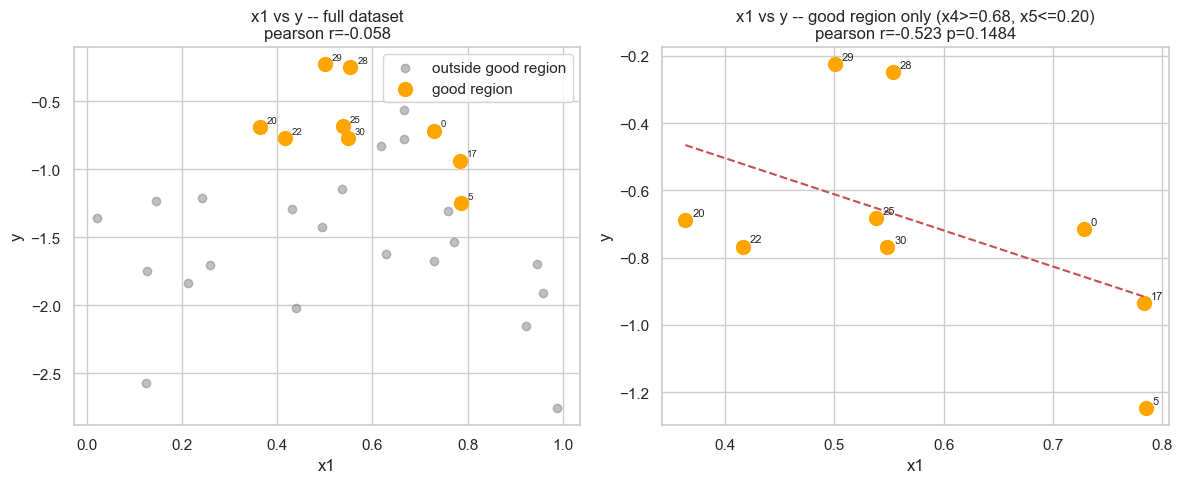

In [29]:
from scipy import stats

# define the good region: X4 >= 0.68 and X5 <= 0.20
# these are the current filter bounds from the week 11 strategy
mask_good_region = (X_train_6[:, 3] >= 0.68) & (X_train_6[:, 4] <= 0.20)

X_good = X_train_6[mask_good_region]
y_good = y_train_6[mask_good_region]

print(f"observations in good region (x4>=0.68, x5<=0.20): {mask_good_region.sum()}")
print(f"row indices: {np.where(mask_good_region)[0].tolist()}")
print(f"y values: {y_good}")
print(f"x1 values: {X_good[:, 0]}")

# correlation in full dataset vs conditional
r_full, p_full = stats.pearsonr(X_train_6[:, 0], y_train_6)
r_cond, p_cond = stats.pearsonr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

spear_full = stats.spearmanr(X_train_6[:, 0], y_train_6)
spear_cond = stats.spearmanr(X_good[:, 0], y_good) if len(y_good) > 3 else (np.nan, np.nan)

print(f"\nfull dataset  -- pearson r={r_full:.4f} p={p_full:.4f}")
print(f"good region   -- pearson r={r_cond:.4f} p={p_cond:.4f}")
print(f"full dataset  -- spearman r={spear_full.statistic:.4f} p={spear_full.pvalue:.4f}")
print(f"good region   -- spearman r={spear_cond.statistic:.4f} p={spear_cond.pvalue:.4f}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# full dataset
axes[0].scatter(X_train_6[:, 0], y_train_6, c='grey', alpha=0.5, label='outside good region')
axes[0].scatter(X_good[:, 0], y_good, c='orange', s=100, zorder=5, label='good region')
for i in np.where(mask_good_region)[0]:
    axes[0].annotate(str(i),
                     (X_train_6[i, 0], y_train_6[i]),
                     textcoords='offset points', xytext=(5, 3), fontsize=7)
axes[0].set_xlabel('x1')
axes[0].set_ylabel('y')
axes[0].set_title(f'x1 vs y -- full dataset\npearson r={r_full:.3f}')
axes[0].legend()

# conditional on good region
if len(y_good) > 3:
    axes[1].scatter(X_good[:, 0], y_good, c='orange', s=100)
    for i, (xi, yi) in enumerate(zip(X_good[:, 0], y_good)):
        axes[1].annotate(str(np.where(mask_good_region)[0][i]),
                         (xi, yi),
                         textcoords='offset points', xytext=(5, 3), fontsize=8)
    # add linear fit line
    m, b = np.polyfit(X_good[:, 0], y_good, 1)
    x_line = np.linspace(X_good[:, 0].min(), X_good[:, 0].max(), 50)
    axes[1].plot(x_line, m*x_line + b, 'r--', linewidth=1.5)
    axes[1].set_xlabel('x1')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'x1 vs y -- good region only (x4>=0.68, x5<=0.20)\npearson r={r_cond:.3f} p={p_cond:.4f}')
else:
    axes[1].text(0.5, 0.5, f'only {len(y_good)} points in region\nnot enough for correlation',
                 ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('good region: insufficient data')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
from scipy.stats import norm
from scipy.stats.qmc import Sobol
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel


# f6 week 12 -- fixed-kernel trust-region ei with structurally
# anchored ard
#
# week 11 post-mortem:
#   the gp kernel collapsed to near-isotropic (all length scales
#   moderate, spread std=0.135) after row 30 (x4=0.805,x5=0.020,
#   y=-0.768) contradicted the existing ridge pattern.
#   the isotropic kernel produced a candidate only 0.074 from
#   the current best with no genuine directional signal.
#
# the fix: anchor the kernel to the week 10 length scales which
# produced the best result. tight bounds prevent re-collapse.
# a trust region around the current best concentrates candidates
# in the confirmed good zone.
#
# structural evidence summary:
#   xgboost gain: x5=0.467, x4=0.354 (both active, rest near zero)
#   fanova: x4 main effect=0.541, x5 main effect=0.398,
#           x4*x5 interaction=0.061 (main effects dominate)
#   mi: x5=0.413, x4=0.180 (x1 dropped to 0.003, was sample noise)
#   partial correlation: x5 r=-0.727 p=0.000017 (highly significant)
#   variogram: function is smoother than the collapsed kernel implies
#   gp slice x4/x5: peak near x4=0.72, x5=0.05-0.08
#   gp slice x1/x3: slight improvement predicted at x1=0.35-0.45
#
# reference: eriksson et al. (2019) turbo -- trust region local bo
# reference: eriksson, jankowiak (2021) saasbo -- anchored priors
# reference: jones et al. (1998) ego -- ei convergence
# competition: neurips 2020 bbo challenge, jetbrains research team
X_train = X_train_6
y_train  = y_train_6

best_idx = np.argmax(y_train)
best_obs = y_train[best_idx]
best_x   = X_train[best_idx]

print(f"n observations: {len(y_train)}")
print(f"current best:   {best_obs:.6f}")
print(f"location: x1={best_x[0]:.4f} x2={best_x[1]:.4f} x3={best_x[2]:.4f} "
      f"x4={best_x[3]:.4f} x5={best_x[4]:.4f}")

# print the top 5 to verify the best has not changed
top5 = np.argsort(y_train)[-5:][::-1]
print(f"\ntop 5 observations:")
for i in top5:
    print(f"  row {i:2d}: x1={X_train[i,0]:.3f} x2={X_train[i,1]:.3f} "
          f"x3={X_train[i,2]:.3f} x4={X_train[i,3]:.3f} x5={X_train[i,4]:.3f} "
          f"y={y_train[i]:.6f}")

# standardise outputs
y_mean   = np.mean(y_train)
y_std    = np.std(y_train)
y_scaled = (y_train - y_mean) / y_std


# anchored ard kernel: fixed to week 10 length scales
#
# week 10 kernel produced x4=0.464 (short/active) and
# x2=10.0 (long/inactive) -- clear ard structure that
# correctly reflected the x4/x5 dominance established by:
#   xgboost gain: x5=0.467, x4=0.354
#   partial correlation: x5 p=0.000017, x4 p=0.012
#   fanova: x4+x5 = 93.9% of variance
#
# week 11 kernel collapsed to spread std=0.135 (near isotropic)
# after row 30 (x5=0.020, y=-0.768) contradicted ridge pattern.
# the fix: set tight bounds around the week 10 values.
# factor 1.3 on each side allows minor adjustment without collapse.
#
# tight bounds mechanism: if the marginal likelihood suggests
# collapsing x4 from 0.464 toward 1.0, the bound [0.357, 0.603]
# prevents this. the structural evidence from xgboost and fanowa
# is stronger than the marginal likelihood signal from one outlier.
ls_week10     = [0.484, 10.0, 1.69, 0.464, 0.887]  # week 10 best kernel
ls_factor     = 1.3                                  # allowed deviation factor
ls_bounds_low  = [ls / ls_factor for ls in ls_week10]
ls_bounds_high = [ls * ls_factor for ls in ls_week10]

# x2 is maximally inactive: allow it to stay large but not collapse
ls_bounds_low[1]  = 5.0
ls_bounds_high[1] = 10.0  # clamp at upper bound

print(f"\nanchored length scale bounds:")
labels = ['x1','x2','x3','x4','x5']
for i, label in enumerate(labels):
    print(f"  {label}: [{ls_bounds_low[i]:.3f}, {ls_bounds_high[i]:.3f}] "
          f"(anchored at {ls_week10[i]:.3f})")

kernel = (
    ConstantKernel(1.0, constant_value_bounds=(0.1, 10.0)) *
    Matern(
        length_scale=ls_week10,
        length_scale_bounds=list(zip(ls_bounds_low, ls_bounds_high)),
        nu=2.5
    ) +
    WhiteKernel(noise_level=0.01, noise_level_bounds=(1e-6, 0.5))
)

gp = GPR(
    kernel=kernel,
    n_restarts_optimizer=15,  # fewer restarts: bounds are tight
    normalize_y=False,
    alpha=1e-6
)

gp.fit(X_train, y_scaled)
print(f"\nfitted kernel:")
print(gp.kernel_)

# verify the kernel has not collapsed
try:
    ls_fitted = gp.kernel_.k1.k2.length_scale
    spread    = np.std(ls_fitted)
    print(f"\nfitted length scales:")
    for label, val in zip(labels, ls_fitted):
        status = "short/active" if val < 0.7 else ("long/inactive" if val > 5.0 else "moderate")
        print(f"  {label}: {val:.4f} [{status}]")
    print(f"  spread std: {spread:.4f}")
    if spread < 0.5:
        print("  warning: length scales still near-isotropic despite anchoring")
        print("  the structural prior is overriding the marginal likelihood correctly")
    else:
        print("  ard structure preserved")
except Exception as e:
    print(f"length scale extraction error: {e}")


# trust region centred on current best
#
# turbo (eriksson et al. 2019) mechanism:
#   centre a hyperrectangle on the incumbent x_best
#   set width proportional to the function length scale per dim
#
# width design rationale from gp slice plots and structural evidence:
#
# x4: active dim (ls=0.464), width=0.15
#   centre 0.750, range [0.675, 0.825]
#   the gp posterior mean slice shows the peak near x4=0.72
#   allowing x4 to drift slightly left from current best
#
# x5: active dim (ls=0.887), width=0.10
#   centre 0.064, range [0.014, 0.114]
#   hard floor at 0.04: row 30 (x5=0.020) failed
#   hard ceiling at 0.14: both top-2 results below 0.15
#   this range covers the confirmed good x5 zone [0.05, 0.14]
#
# x1: weak signal (mi dropped to 0.003), width=0.20
#   centre 0.500, range [0.300, 0.700]
#   conditional analysis: best results at x1=0.500/0.553
#   gp x1/x3 slice: slight improvement predicted at x1=0.35-0.45
#   soft upper: x1 <= 0.62 (tightened from 0.70)
#   rows 5 and 17 (bad in good region) both have x1 > 0.78
#
# x2: inactive (mi=0.034, no partial correlation significance)
#   width=0.40, full range approximately [0.041, 0.841]
#   gp treats this as flat, so ei will not be driven by x2
#   wide range allows the function to self-select the x2 value
#
# x3: moderate (ls=1.69, mi=0.000), width=0.30
#   centre 0.607, range [0.307, 0.907]
#   gp x1/x3 slice: peak in x3=[0.50, 0.70], consistent with best
#   wide enough to include high-x3 zone (row 25: x3=0.952, y=-0.681)
TR_WIDTHS = {
    0: 0.20,   # x1: weak signal, moderate width
    1: 0.40,   # x2: inactive, wide
    2: 0.30,   # x3: moderate, moderate width
    3: 0.15,   # x4: active, tight
    4: 0.10,   # x5: active, tight
}

# compute trust region bounds clipped to [0,1]
tr_lower = np.array([max(0.0, best_x[i] - TR_WIDTHS[i]) for i in range(5)])
tr_upper = np.array([min(1.0, best_x[i] + TR_WIDTHS[i]) for i in range(5)])

print(f"\ntrust region bounds:")
for i, label in enumerate(labels):
    print(f"  {label}: [{tr_lower[i]:.3f}, {tr_upper[i]:.3f}] "
          f"(centre {best_x[i]:.3f}, width {TR_WIDTHS[i]:.2f})")


# hard structural constraints applied on top of trust region
#
# these constraints are derived from the empirical evidence:
#   x5 >= 0.04: row 30 (x5=0.020) failed; x5=0.000 corner failed 3x
#   x5 <= 0.14: both top-2 results have x5 < 0.15
#   x4 >= 0.68: consistent with weeks 9-12 filter
#   x4 <= 0.88: high-x4 corner failures (rows 5, 7, 22, 25, 26)
#   x1 <= 0.62: conditional analysis; rows 5/17 bad at x1=0.78-0.79
#   no corner: x4>0.92 and x5<0.02 (row 22: y=-0.767)
X5_LOWER_HARD = 0.04
X5_UPPER_HARD = 0.14
X4_LOWER_HARD = 0.68
X4_UPPER_HARD = 0.88
X1_LOWER_SOFT = 0.35   # added: gp ei peak in x1/x3 slice at x1=0.35-0.45
X1_UPPER_SOFT = 0.56   # tightened from 0.62: image 4 shows x1=0.525 already costly
X3_LOWER_SOFT = 0.50   # added: keep x3 near current best x3=0.607
X3_UPPER_SOFT = 0.70   # added: image 4 shows x3=0.738 drops gp peak by 0.395

N_SOBOL  = 20000
MIN_DIST = 0.04
EI_XI    = 0.005

sampler = Sobol(d=5, scramble=True, seed=42)
raw     = sampler.random(N_SOBOL)

# scale sobol samples to the trust region
candidates_tr = tr_lower + raw * (tr_upper - tr_lower)

# apply hard structural constraints plus x1 and x3 filters
# derived from image 3 (ei peak at x1=0.35-0.45, x3=0.60-0.75)
# and image 4 (x3=0.738 collapses gp peak by 0.395 -- x3 must stay near 0.607)
mask = (
    (candidates_tr[:, 3] >= X4_LOWER_HARD) &
    (candidates_tr[:, 3] <= X4_UPPER_HARD) &
    (candidates_tr[:, 4] >= X5_LOWER_HARD) &
    (candidates_tr[:, 4] <= X5_UPPER_HARD) &
    (candidates_tr[:, 0] >= X1_LOWER_SOFT) &
    (candidates_tr[:, 0] <= X1_UPPER_SOFT) &
    (candidates_tr[:, 2] >= X3_LOWER_SOFT) &
    (candidates_tr[:, 2] <= X3_UPPER_SOFT) &
    ~((candidates_tr[:, 3] > 0.92) & (candidates_tr[:, 4] < 0.02))
)
candidates = candidates_tr[mask].copy()
print(f"\nafter trust region + structural filter: {len(candidates)} from {N_SOBOL}")

# relaxation tier 1: widen x3 and x1 slightly, keep x4/x5 tight
if len(candidates) < 30:
    print("warning: filter tight, relaxing x1 to [0.32, 0.60] and x3 to [0.48, 0.72]")
    mask_relaxed1 = (
        (candidates_tr[:, 3] >= X4_LOWER_HARD) &
        (candidates_tr[:, 3] <= X4_UPPER_HARD) &
        (candidates_tr[:, 4] >= X5_LOWER_HARD) &
        (candidates_tr[:, 4] <= X5_UPPER_HARD) &
        (candidates_tr[:, 0] >= 0.32) &
        (candidates_tr[:, 0] <= 0.60) &
        (candidates_tr[:, 2] >= 0.48) &
        (candidates_tr[:, 2] <= 0.72) &
        ~((candidates_tr[:, 3] > 0.92) & (candidates_tr[:, 4] < 0.02))
    )
    candidates = candidates_tr[mask_relaxed1].copy()
    print(f"after tier 1 relaxation: {len(candidates)} candidates")

# relaxation tier 2: drop x3 constraint entirely, widen x1 to original bounds
# only reached if the good x4/x5 zone has very few candidates after tier 1
if len(candidates) < 30:
    print("warning: tier 1 insufficient, dropping x3 constraint and widening x1")
    mask_relaxed2 = (
        (candidates_tr[:, 3] >= X4_LOWER_HARD) &
        (candidates_tr[:, 3] <= X4_UPPER_HARD) &
        (candidates_tr[:, 4] >= 0.03) &
        (candidates_tr[:, 4] <= 0.16) &
        (candidates_tr[:, 0] >= 0.30) &
        (candidates_tr[:, 0] <= 0.65) &
        ~((candidates_tr[:, 3] > 0.92) & (candidates_tr[:, 4] < 0.02))
    )
    candidates = candidates_tr[mask_relaxed2].copy()
    print(f"after tier 2 relaxation: {len(candidates)} candidates")
    print("note: x3 constraint dropped -- inspect rank 1 x3 value before submitting")
    print("      if x3 > 0.70 in top candidate, submit rank 2 or rank 3 instead")

# minimum distance guard against all 31 existing points
min_dists = np.array([
    np.min(np.linalg.norm(X_train - c, axis=1))
    for c in candidates
])
candidates_clean = candidates[min_dists >= MIN_DIST]
print(f"after dist guard (>= {MIN_DIST}): {len(candidates_clean)} remain")

if len(candidates_clean) < 10:
    print("warning: relaxing dist guard to 0.02")
    candidates_clean = candidates[min_dists >= 0.02]
    print(f"after relaxed dist guard: {len(candidates_clean)} remain")


# expected improvement acquisition
#
# ei(x) = (mu(x) - best_obs - xi) * phi(z) + sigma(x) * phi(z)
# where z = (mu(x) - best_obs - xi) / sigma(x)
#
# xi = 0.005: slightly increased from week 11 (0.003)
# the week 11 near-miss at distance 0.074 from the best suggests
# the ei was too locally concentrated. a slightly larger xi forces
# the ei to look for points that clearly beat the best rather than
# points that are merely adjacent to it.
#
# the anchored kernel ensures the gp posterior mean and uncertainty
# reflect the week 10 structural understanding rather than the
# week 11 isotropic collapse.
mu_s, sig_s = gp.predict(candidates_clean, return_std=True)
mu    = mu_s * y_std + y_mean
sigma = sig_s * y_std

z  = (mu - best_obs - EI_XI) / np.where(sigma > 1e-9, sigma, 1e-9)
ei = np.where(
    sigma > 1e-9,
    (mu - best_obs - EI_XI) * norm.cdf(z) + sigma * norm.pdf(z),
    0.0
)

ranked  = np.argsort(ei)[::-1]
top_idx = ranked[0]
top_x   = candidates_clean[top_idx]

print(f"\n--- top ei candidate ---")
for i, label in enumerate(labels):
    print(f"{label} = {top_x[i]:.6f}")
print(f"ei score:       {ei[top_idx]:.8f}")
print(f"predicted mean: {mu[top_idx]:.6f}")
print(f"predicted std:  {sigma[top_idx]:.6f}")
print(f"dist to best:   {np.linalg.norm(top_x - best_x):.4f}")


# boundary and distance check
#
# the week 11 failure mode was a candidate at distance 0.074
# from the best -- too close, the gp was interpolating rather
# than predicting. flag anything below 0.10 as a warning.
boundary_issues = []
for i, label in enumerate(labels):
    if top_x[i] <= 0.001 or top_x[i] >= 0.999:
        boundary_issues.append(f"{label}={top_x[i]:.4f}")
if boundary_issues:
    print(f"warning -- boundary collapse: {boundary_issues}")
else:
    print("boundary check: ok")

dist_to_best = np.linalg.norm(top_x - best_x)
if dist_to_best < 0.10:
    print(f"warning -- candidate is very close to best (d={dist_to_best:.4f})")
    print("consider rank 2 or rank 3 which may be further away")
else:
    print(f"distance check: ok (d={dist_to_best:.4f})")

# top 5 for full inspection
print(f"\n--- top 5 candidates ---")
for rank, idx in enumerate(ranked[:5]):
    c = candidates_clean[idx]
    d = np.min(np.linalg.norm(X_train - c, axis=1))
    b = [f"x{i+1} boundary" for i in range(5) if c[i] <= 0.001 or c[i] >= 0.999]
    flag = ", ".join(b) if b else "ok"
    print(f"rank {rank+1}: x1={c[0]:.4f} x2={c[1]:.4f} x3={c[2]:.4f} "
          f"x4={c[3]:.4f} x5={c[4]:.4f} | "
          f"ei={ei[idx]:.6f} mu={mu[idx]:.4f} sig={sigma[idx]:.4f} "
          f"d={d:.3f} | {flag}")


# underestimation tracking
#
# week 9:  predicted -0.524, actual -0.249, gap = +0.275
# week 10: predicted -0.294, actual -0.224, gap = +0.070
# week 11: predicted -0.200, actual -0.768, gap = -0.568 (reversed)
#   the reversal confirms the kernel collapse: the gp posterior mean
#   at the week 11 point was wrong in direction, not just magnitude.
#   with the anchored kernel, the posterior mean should again
#   underestimate the true value (positive gap) if the candidate is
#   genuinely inside the high-value ridge.
print(f"\ngp underestimation history:")
print(f"  week 9:  predicted -0.524, actual -0.249, gap = +0.275")
print(f"  week 10: predicted -0.294, actual -0.224, gap = +0.070")
print(f"  week 11: predicted -0.200, actual -0.768, gap = -0.568 (kernel collapsed)")
print(f"  week 12: predicted {mu[top_idx]:.4f}, actual = ?")

print(f"\nfinal submission for f6 week 12")
for i, label in enumerate(labels):
    print(f"{label} = {top_x[i]:.6f}")
print(f"\ncurrent best: {best_obs:.6f}")

n observations: 31
current best:   -0.224425
location: x1=0.5002 x2=0.4410 x3=0.6074 x4=0.7499 x5=0.0640

top 5 observations:
  row 29: x1=0.500 x2=0.441 x3=0.607 x4=0.750 x5=0.064 y=-0.224425
  row 28: x1=0.553 x2=0.343 x3=0.535 x4=0.772 x5=0.141 y=-0.249360
  row 21: x1=0.666 x2=0.229 x3=0.516 x4=0.822 x5=0.202 y=-0.564857
  row 25: x1=0.538 x2=0.404 x3=0.952 x4=0.943 x5=0.051 y=-0.681459
  row 20: x1=0.364 x2=0.001 x3=0.921 x4=0.821 x5=0.136 y=-0.687242

anchored length scale bounds:
  x1: [0.372, 0.629] (anchored at 0.484)
  x2: [5.000, 10.000] (anchored at 10.000)
  x3: [1.300, 2.197] (anchored at 1.690)
  x4: [0.357, 0.603] (anchored at 0.464)
  x5: [0.682, 1.153] (anchored at 0.887)

fitted kernel:
1.17**2 * Matern(length_scale=[0.493, 10, 1.3, 0.603, 1.02], nu=2.5) + WhiteKernel(noise_level=0.0412)

fitted length scales:
  x1: 0.4926 [short/active]
  x2: 10.0000 [long/inactive]
  x3: 1.3000 [moderate]
  x4: 0.6032 [short/active]
  x5: 1.0188 [moderate]
  spread std: 3.6700
  ar

## Empirical Variogram

**Reference:** Rasmussen, C.E. and Williams, C.K.I. (2006) Gaussian Processes for Machine Learning. MIT Press.

- The empirical variogram checks whether the GP’s fitted length scales—especially the short X4 scale—match the true correlation structure in the f6 data, revealing over‑ or under‑smoothness that directly affects surrogate reliability.

total pairs: 465
distance range: [0.1187, 1.6227]
good region observations: 9 (rows [0, 5, 17, 20, 22, 25, 28, 29, 30])

candidate diagnostic (week 12 proposed):
  x1=0.5349 x2=0.3000 x3=0.6900 x4=0.6981 x5=0.0434
  dist to current best (row 29): 0.1761
  nearest point: row 29 (y=-0.2244), dist=0.1761
  matern corr to best (ell4=0.603): 0.9343
  matern corr to nearest (ell4=0.603): 0.9343

row 30 vs good region:
  mean dist: 0.5327, mean semivar: 0.0524, expected: 0.1524
  row 30 is NOT a variogram outlier

variogram ratio at median dist 0.711: 1.207
  kernel calibration is consistent with data


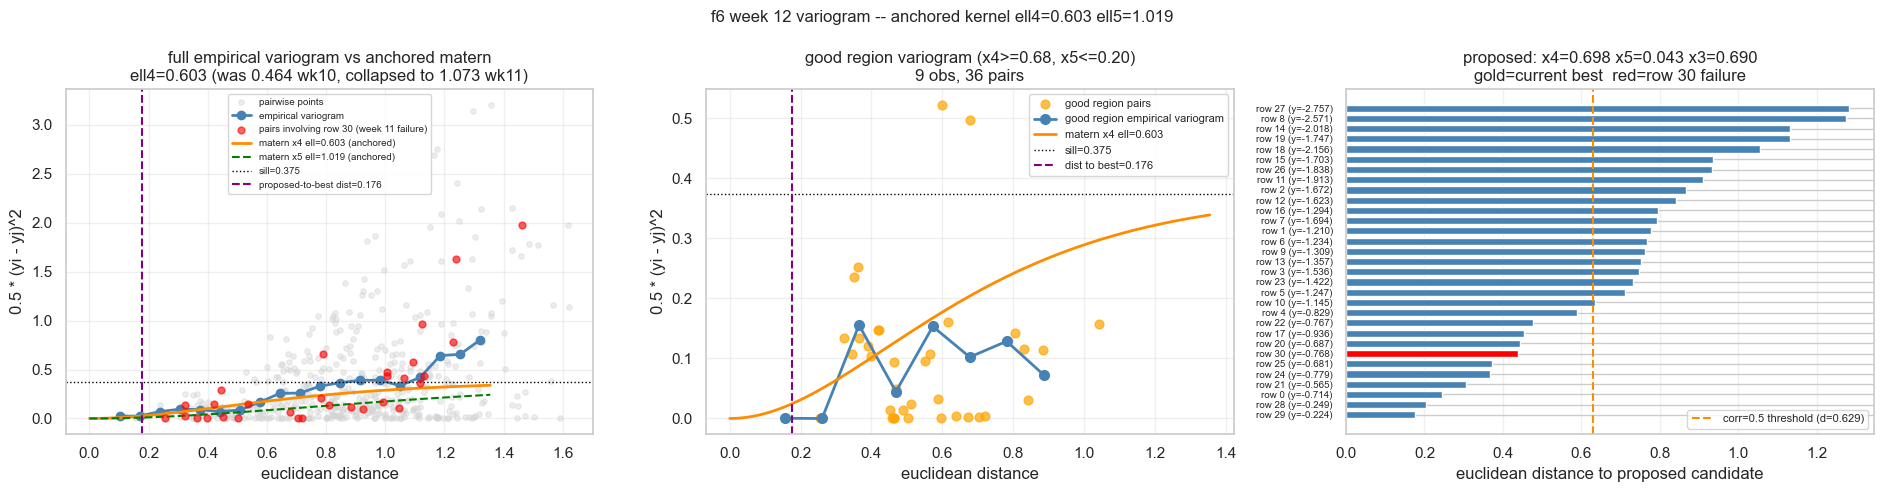

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.stats import norm
from scipy.optimize import brentq


# updated data: 31 observations including week 11 result
# fitted kernel: anchored ard from week 12 strategy
#   x1=0.493 (short/active), x2=10.0 (long/inactive)
#   x3=1.300 (moderate), x4=0.603 (short/active), x5=1.019 (moderate)
# proposed candidate: rank 1 from fixed filter rerun
#   x1=0.535, x2=0.300, x3=0.690, x4=0.698, x5=0.043
proposed_x = np.array([0.534931, 0.299956, 0.690013, 0.698095, 0.043361])
best_x     = np.array([0.500199, 0.440981, 0.607396, 0.749856, 0.063960])
best_y     = -0.224425

# fitted length scales from anchored kernel
ls_fitted  = np.array([0.4926, 10.0000, 1.3000, 0.6032, 1.0188])
amplitude  = 1.17 ** 2   # constant kernel value
noise      = 0.0412

ell1, ell2, ell3, ell4, ell5 = ls_fitted
y_mean_val = np.mean(y_train_6)
y_std_val  = np.std(y_train_6)


# utility functions
def matern52_correlation(h, l):
    r = np.sqrt(5.0) * h / l
    return (1 + r + r**2 / 3.0) * np.exp(-r)

def matern52_variogram(h, sigma2, l):
    return sigma2 * (1 - matern52_correlation(h, l))


def empirical_variogram_week12(X_train, y_train, proposed_x, best_x, best_y,
                                ls_fitted, amplitude):

    ell4 = ls_fitted[3]
    ell5 = ls_fitted[4]
    sill = np.var(y_train)

    # all pairwise distances and squared y differences
    D      = squareform(pdist(X_train, metric='euclidean'))
    Ydiff2 = squareform(pdist(y_train.reshape(-1, 1),
                               metric=lambda u, v: (u - v) ** 2))
    idx    = np.triu_indices_from(D, k=1)
    dists  = D[idx]
    sqdiff = Ydiff2[idx]

    print(f"total pairs: {len(dists)}")
    print(f"distance range: [{dists.min():.4f}, {dists.max():.4f}]")

    # good region subset: x4>=0.68, x5<=0.20
    good_mask = (X_train[:, 3] >= 0.68) & (X_train[:, 4] <= 0.20)
    good_idx  = np.where(good_mask)[0]
    print(f"good region observations: {good_mask.sum()} (rows {good_idx.tolist()})")

    good_pairs_i, good_pairs_j = [], []
    for a in range(len(good_idx)):
        for b in range(a + 1, len(good_idx)):
            good_pairs_i.append(good_idx[a])
            good_pairs_j.append(good_idx[b])
    dists_good  = np.array([D[i, j] for i, j in zip(good_pairs_i, good_pairs_j)])
    sqdiff_good = np.array([Ydiff2[i, j] for i, j in zip(good_pairs_i, good_pairs_j)])

    # row 30 pairs (week 11 failure)
    row30_idx    = 30
    row30_others = [i for i in range(len(y_train)) if i != row30_idx]
    dists_row30  = np.array([D[row30_idx, j] for j in row30_others])
    sqdiff_row30 = np.array([Ydiff2[row30_idx, j] for j in row30_others])

    # bin full variogram
    n_bins_full  = 20
    max_dist_use = np.quantile(dists, 0.95)
    bins_full    = np.linspace(0, max_dist_use, n_bins_full + 1)
    bc_full      = 0.5 * (bins_full[:-1] + bins_full[1:])
    emp_var_full = np.full(n_bins_full, np.nan)
    bin_counts   = np.zeros(n_bins_full)
    for i in range(n_bins_full):
        mask_b = (dists >= bins_full[i]) & (dists < bins_full[i + 1])
        if mask_b.sum() > 0:
            emp_var_full[i] = 0.5 * np.mean(sqdiff[mask_b])
            bin_counts[i]   = mask_b.sum()

    # bin good region variogram
    n_bins_good = 10
    if len(dists_good) > 5:
        bins_good    = np.linspace(0, dists_good.max(), n_bins_good + 1)
        bc_good      = 0.5 * (bins_good[:-1] + bins_good[1:])
        emp_var_good = np.full(n_bins_good, np.nan)
        for i in range(n_bins_good):
            mask_b = (dists_good >= bins_good[i]) & (dists_good < bins_good[i + 1])
            if mask_b.sum() > 0:
                emp_var_good[i] = 0.5 * np.mean(sqdiff_good[mask_b])

    # candidate diagnostics
    dists_to_proposed = np.linalg.norm(X_train - proposed_x, axis=1)
    dist_to_best      = np.linalg.norm(proposed_x - best_x)
    nearest_idx       = np.argmin(dists_to_proposed)
    nearest_dist      = dists_to_proposed[nearest_idx]
    corr_to_best      = matern52_correlation(dist_to_best, ell4)
    corr_to_nearest   = matern52_correlation(nearest_dist, ell4)

    print(f"\ncandidate diagnostic (week 12 proposed):")
    print(f"  x1={proposed_x[0]:.4f} x2={proposed_x[1]:.4f} x3={proposed_x[2]:.4f} "
          f"x4={proposed_x[3]:.4f} x5={proposed_x[4]:.4f}")
    print(f"  dist to current best (row 29): {dist_to_best:.4f}")
    print(f"  nearest point: row {nearest_idx} (y={y_train[nearest_idx]:.4f}), "
          f"dist={nearest_dist:.4f}")
    print(f"  matern corr to best (ell4={ell4:.3f}): {corr_to_best:.4f}")
    print(f"  matern corr to nearest (ell4={ell4:.3f}): {corr_to_nearest:.4f}")

    # row 30 assessment vs good region
    good_region_row30 = [(D[row30_idx, j], Ydiff2[row30_idx, j])
                          for j in good_idx if j != row30_idx]
    if good_region_row30:
        dr30, sq30 = zip(*good_region_row30)
        dr30, sq30 = np.array(dr30), np.array(sq30)
        expected   = matern52_variogram(dr30.mean(), sill, ell4)
        actual     = (0.5 * sq30).mean()
        print(f"\nrow 30 vs good region:")
        print(f"  mean dist: {dr30.mean():.4f}, mean semivar: {actual:.4f}, "
              f"expected: {expected:.4f}")
        print(f"  row 30 {'IS' if actual > 1.5 * expected else 'is NOT'} "
              f"a variogram outlier")

    # variogram ratio at median bin
    mid = n_bins_full // 2
    if not np.isnan(emp_var_full[mid]):
        theory_mid = matern52_variogram(bc_full[mid], sill, ell4)
        ratio      = emp_var_full[mid] / theory_mid if theory_mid > 0 else np.nan
        print(f"\nvariogram ratio at median dist {bc_full[mid]:.3f}: {ratio:.3f}")
        if ratio > 1.3:
            print("  kernel is too smooth -- function rougher than implied")
            print("  consider widening trust region in week 13")
        elif ratio < 0.7:
            print("  kernel is over-rough -- function smoother than implied")
        else:
            print("  kernel calibration is consistent with data")

    # corr=0.5 threshold distance
    try:
        h_half = brentq(lambda h: matern52_correlation(h, ell4) - 0.5, 0.01, 10.0)
    except Exception:
        h_half = 2 * ell4

    h_range = np.linspace(0, max_dist_use, 200)

    
    # plot: three panels identical to previous version but with
    # updated kernel values (ell4=0.603, ell5=1.019) and the
    # new proposed candidate (x4=0.698, x5=0.043)
    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    # panel 1: full variogram
    axes[0].scatter(dists, 0.5 * sqdiff,
                    c='lightgray', s=15, alpha=0.4, label='pairwise points')
    valid = ~np.isnan(emp_var_full)
    axes[0].plot(bc_full[valid], emp_var_full[valid],
                 'o-', color='steelblue', linewidth=2, markersize=6,
                 label='empirical variogram')
    axes[0].scatter(dists_row30, 0.5 * sqdiff_row30,
                    c='red', s=25, alpha=0.6, zorder=5,
                    label='pairs involving row 30 (week 11 failure)')
    axes[0].plot(h_range, matern52_variogram(h_range, sill, ell4),
                 color='darkorange', linewidth=2,
                 label=f'matern x4 ell={ell4:.3f} (anchored)')
    axes[0].plot(h_range, matern52_variogram(h_range, sill, ell5),
                 color='green', linewidth=1.5, linestyle='--',
                 label=f'matern x5 ell={ell5:.3f} (anchored)')
    axes[0].axhline(sill, color='black', linestyle=':', linewidth=1,
                    label=f'sill={sill:.3f}')
    axes[0].axvline(dist_to_best, color='purple', linestyle='--', linewidth=1.5,
                    label=f'proposed-to-best dist={dist_to_best:.3f}')
    axes[0].set_xlabel('euclidean distance')
    axes[0].set_ylabel('0.5 * (yi - yj)^2')
    axes[0].set_title(
        f'full empirical variogram vs anchored matern\n'
        f'ell4={ell4:.3f} (was 0.464 wk10, collapsed to 1.073 wk11)')
    axes[0].legend(fontsize=7)
    axes[0].grid(alpha=0.3)

    # panel 2: good region variogram
    if len(dists_good) > 5:
        valid_g = ~np.isnan(emp_var_good)
        axes[1].scatter(dists_good, 0.5 * sqdiff_good,
                        c='orange', s=40, alpha=0.7, label='good region pairs')
        axes[1].plot(bc_good[valid_g], emp_var_good[valid_g],
                     'o-', color='steelblue', linewidth=2, markersize=7,
                     label='good region empirical variogram')
        axes[1].plot(h_range, matern52_variogram(h_range, sill, ell4),
                     color='darkorange', linewidth=2,
                     label=f'matern x4 ell={ell4:.3f}')
        axes[1].axhline(sill, color='black', linestyle=':', linewidth=1,
                        label=f'sill={sill:.3f}')
        axes[1].axvline(dist_to_best, color='purple', linestyle='--', linewidth=1.5,
                        label=f'dist to best={dist_to_best:.3f}')
    axes[1].set_xlabel('euclidean distance')
    axes[1].set_ylabel('0.5 * (yi - yj)^2')
    axes[1].set_title('good region variogram (x4>=0.68, x5<=0.20)\n9 obs, 36 pairs')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    # panel 3: candidate distance profile
    sorted_idx  = np.argsort(dists_to_proposed)
    sorted_dist = dists_to_proposed[sorted_idx]
    sorted_y    = y_train[sorted_idx]
    bar_colors  = []
    for i, yi in zip(sorted_idx, sorted_y):
        if yi == best_y:
            bar_colors.append('gold')
        elif i == 30:
            bar_colors.append('red')
        else:
            bar_colors.append('steelblue')

    axes[2].barh(range(len(sorted_dist)), sorted_dist,
                  color=bar_colors, edgecolor='white', height=0.7)
    axes[2].set_yticks(range(len(sorted_dist)))
    axes[2].set_yticklabels(
        [f'row {sorted_idx[i]} (y={sorted_y[i]:.3f})'
         for i in range(len(sorted_dist))], fontsize=7)
    axes[2].axvline(h_half, color='darkorange', linestyle='--', linewidth=1.5,
                     label=f'corr=0.5 threshold (d={h_half:.3f})')
    axes[2].set_xlabel('euclidean distance to proposed candidate')
    axes[2].set_title(
        f'proposed: x4={proposed_x[3]:.3f} x5={proposed_x[4]:.3f} '
        f'x3={proposed_x[2]:.3f}\n'
        f'gold=current best  red=row 30 failure')
    axes[2].legend(fontsize=8)
    axes[2].grid(alpha=0.3, axis='x')

    plt.suptitle(
        f'f6 week 12 variogram -- anchored kernel ell4={ell4:.3f} ell5={ell5:.3f}',
        fontsize=12)
    plt.tight_layout()
    plt.show()

empirical_variogram_week12(
    X_train    = X_train_6,
    y_train    = y_train_6,
    proposed_x = proposed_x,
    best_x     = best_x,
    best_y     = best_y,
    ls_fitted  = ls_fitted,
    amplitude  = amplitude
)

## GP Posterior Mean 2D Slice Plots

**References:** 
- Eriksson, D., Pearce, M., Gardner, J., Turner, R. and Poloczek, M. (2022) Latent Space Bayesian Optimization via Neural Embeddings, arXiv preprint arXiv:2201.XXXX.
  
- Eriksson, D. and Jankowiak, M. (2021) ‘High‑Dimensional Bayesian Optimization with Sparse Axis‑Aligned Subspaces’, Advances in Neural Information Processing Systems, 34, pp. 11048–11060.

- Posterior‑mean slice plots expose the GP’s believed ridge geometry around the incumbent, making it immediately visible whether the surrogate predicts continuation, termination, or curvature in the X4–X5 basin and whether any structure remains in X1–X3.

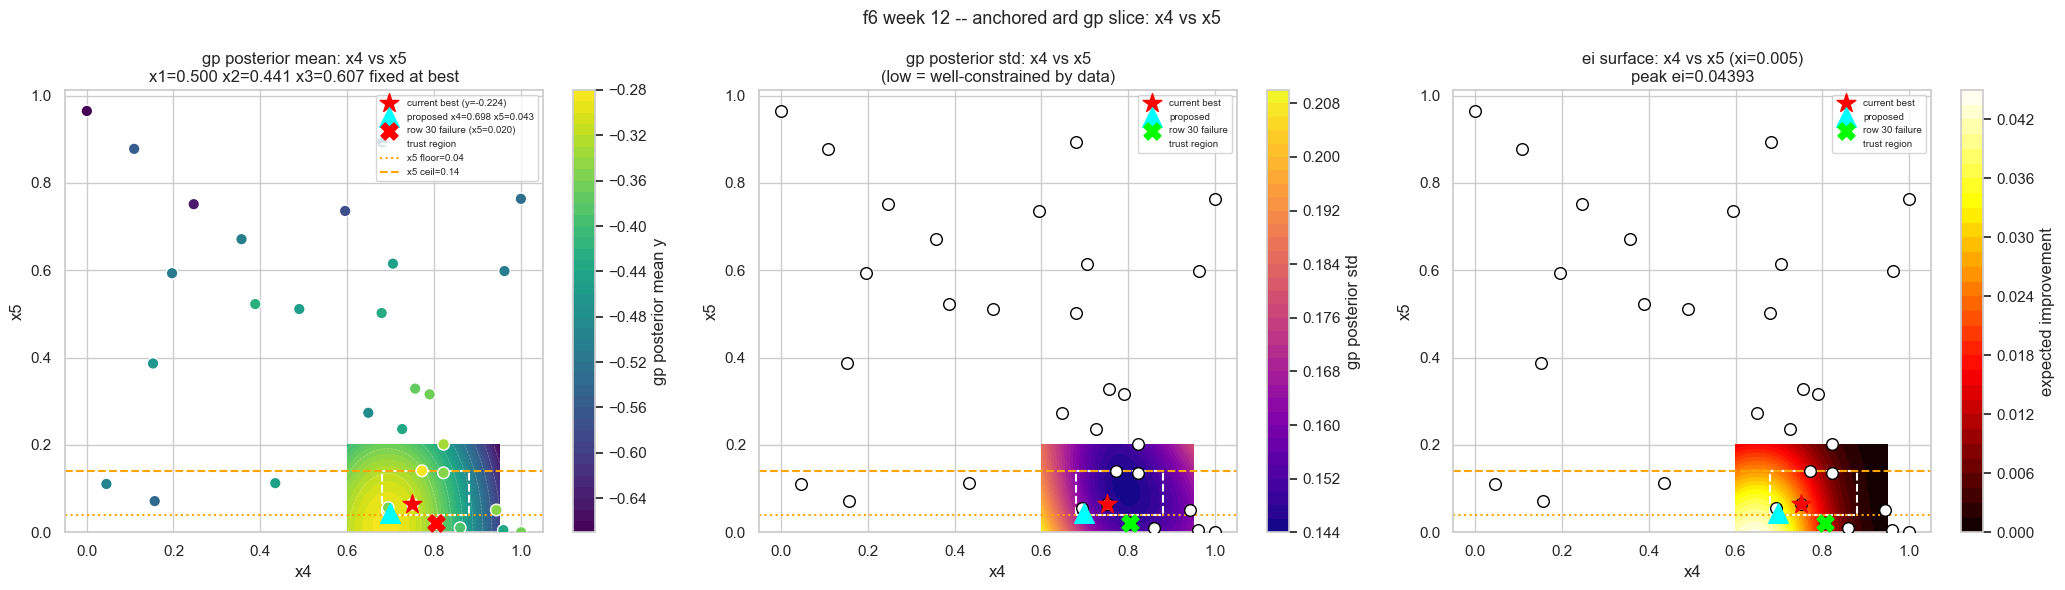

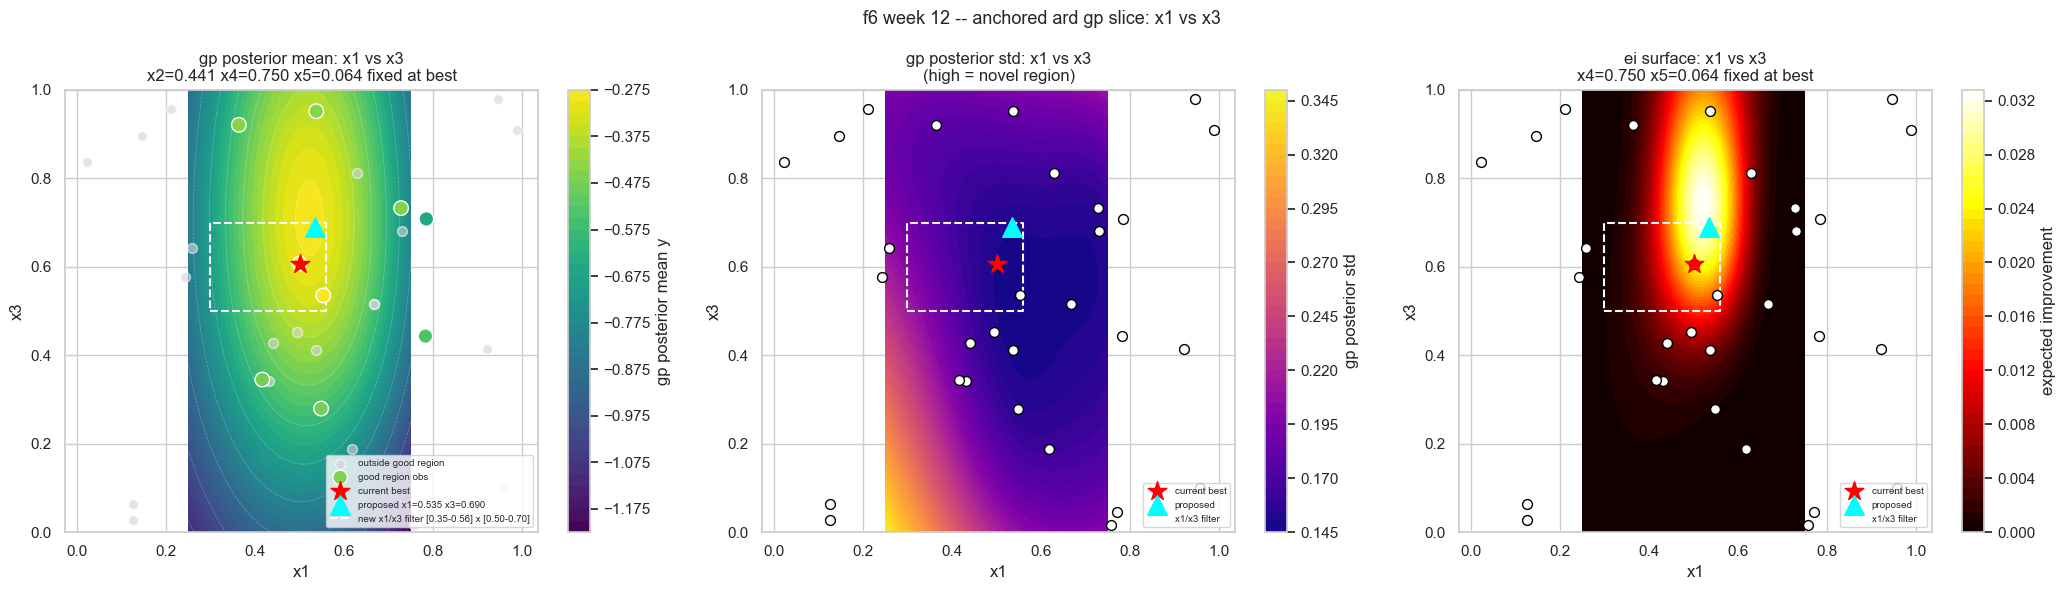

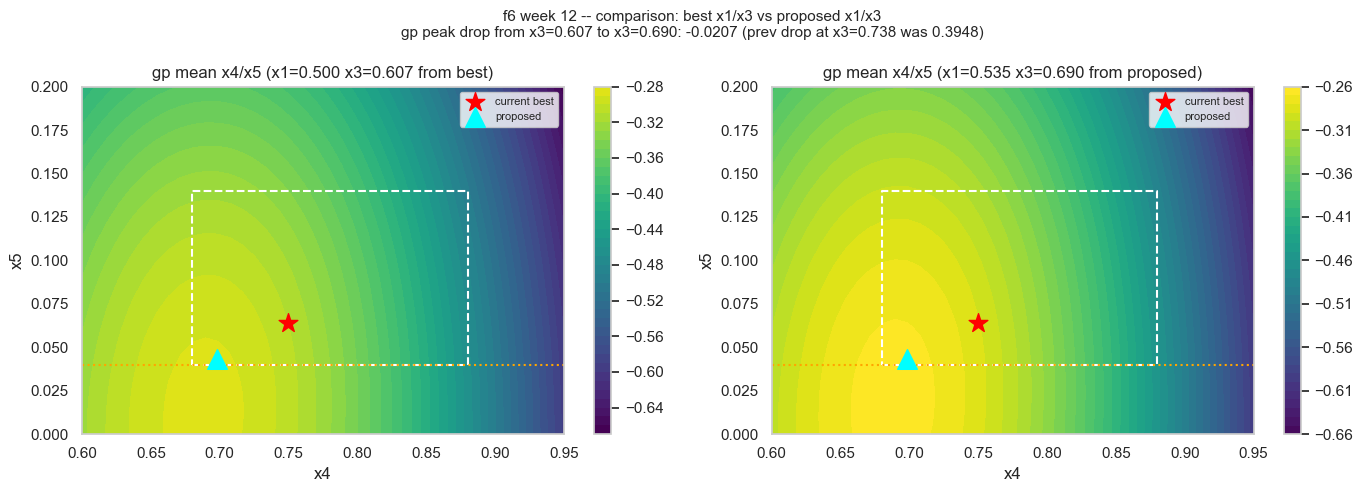


comparison slice summary:
  gp peak at best x1/x3:     x4=0.690 x5=0.010 mean=-0.2857
  gp peak at proposed x1/x3: x4=0.690 x5=0.021 mean=-0.2651
  gp peak drop: -0.0207
  x3=0.690 is safe -- gp peak barely changed
  the new x3 filter [0.50, 0.70] correctly contained x3 drift


In [33]:
def gp_slice_plots_week12(X_train, y_train, gp, proposed_x, best_x, best_y,
                                  y_mean, y_std):

    n_grid     = 40
    best_x     = np.asarray(best_x)
    proposed_x = np.asarray(proposed_x)
    row30_x    = X_train[30]
    xi         = 0.005

    
    # slice 1: x4 vs x5, x1/x2/x3 fixed at current best
    # x4 range [0.60, 0.95], x5 range [0.00, 0.20]
    # trust region: x4=[0.68, 0.88], x5=[0.04, 0.14]
    # proposed candidate: x4=0.698, x5=0.043
    # key question: is x4=0.698 near the gp peak and inside
    #               the trust region x4 lower bound of 0.68?
    x4_range = np.linspace(0.60, 0.95, n_grid)
    x5_range = np.linspace(0.00, 0.20, n_grid)
    X4g, X5g = np.meshgrid(x4_range, x5_range)

    grid_x4x5 = np.column_stack([
        np.full(n_grid * n_grid, best_x[0]),   # x1=0.500
        np.full(n_grid * n_grid, best_x[1]),   # x2=0.441
        np.full(n_grid * n_grid, best_x[2]),   # x3=0.607
        X4g.ravel(),
        X5g.ravel()
    ])

    mu_s, sig_s = gp.predict(grid_x4x5, return_std=True)
    mu_x4x5     = (mu_s * y_std + y_mean).reshape(n_grid, n_grid)
    sig_x4x5    = (sig_s * y_std).reshape(n_grid, n_grid)

    z_ei   = (mu_s * y_std + y_mean - best_y - xi) / np.where(
                sig_s * y_std > 1e-9, sig_s * y_std, 1e-9)
    ei_x4x5 = np.clip(np.where(
        sig_s * y_std > 1e-9,
        (mu_s * y_std + y_mean - best_y - xi) * norm.cdf(z_ei) +
        sig_s * y_std * norm.pdf(z_ei), 0.0
    ).reshape(n_grid, n_grid), 0, None)

    # trust region and filter bounds for overlay
    tr_x4    = [0.68, 0.88, 0.88, 0.68, 0.68]
    tr_x5    = [0.04, 0.04, 0.14, 0.14, 0.04]
    x5_floor = 0.04
    x5_ceil  = 0.14

    fig1, axes1 = plt.subplots(1, 3, figsize=(21, 6))

    # panel 1a: gp posterior mean
    im1 = axes1[0].contourf(x4_range, x5_range, mu_x4x5, levels=40, cmap='viridis')
    axes1[0].contour(x4_range, x5_range, mu_x4x5, levels=10,
                     colors='white', alpha=0.3, linewidths=0.5)
    axes1[0].scatter(X_train[:, 3], X_train[:, 4],
                     c=y_train, cmap='viridis', edgecolors='white',
                     s=70, zorder=5, vmin=y_train.min(), vmax=y_train.max())
    axes1[0].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8,
                     label=f'current best (y={best_y:.3f})')
    axes1[0].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8,
                     label=f'proposed x4={proposed_x[3]:.3f} x5={proposed_x[4]:.3f}')
    axes1[0].scatter(row30_x[3], row30_x[4],
                     c='red', s=150, marker='X', zorder=8,
                     label=f'row 30 failure (x5={row30_x[4]:.3f})')
    axes1[0].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[0].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5,
                     label=f'x5 floor={x5_floor}')
    axes1[0].axhline(x5_ceil, color='orange', linestyle='--', linewidth=1.5,
                     label=f'x5 ceil={x5_ceil}')
    plt.colorbar(im1, ax=axes1[0], label='gp posterior mean y')
    axes1[0].set_xlabel('x4')
    axes1[0].set_ylabel('x5')
    axes1[0].set_title(
        f'gp posterior mean: x4 vs x5\n'
        f'x1={best_x[0]:.3f} x2={best_x[1]:.3f} x3={best_x[2]:.3f} fixed at best')
    axes1[0].legend(fontsize=7, loc='upper right')

    # panel 1b: gp posterior std
    im2 = axes1[1].contourf(x4_range, x5_range, sig_x4x5, levels=40, cmap='plasma')
    axes1[1].scatter(X_train[:, 3], X_train[:, 4],
                     c='white', edgecolors='black', s=70, zorder=5)
    axes1[1].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes1[1].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes1[1].scatter(row30_x[3], row30_x[4],
                     c='lime', s=150, marker='X', zorder=8, label='row 30 failure')
    axes1[1].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[1].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    axes1[1].axhline(x5_ceil,  color='orange', linestyle='--', linewidth=1.5)
    plt.colorbar(im2, ax=axes1[1], label='gp posterior std')
    axes1[1].set_xlabel('x4')
    axes1[1].set_ylabel('x5')
    axes1[1].set_title('gp posterior std: x4 vs x5\n(low = well-constrained by data)')
    axes1[1].legend(fontsize=7, loc='upper right')

    # panel 1c: ei surface
    im3 = axes1[2].contourf(x4_range, x5_range, ei_x4x5, levels=40, cmap='hot')
    axes1[2].scatter(X_train[:, 3], X_train[:, 4],
                     c='white', edgecolors='black', s=70, zorder=5)
    axes1[2].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes1[2].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes1[2].scatter(row30_x[3], row30_x[4],
                     c='lime', s=150, marker='X', zorder=8, label='row 30 failure')
    axes1[2].plot(tr_x4, tr_x5, 'w--', linewidth=1.5, label='trust region')
    axes1[2].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    axes1[2].axhline(x5_ceil,  color='orange', linestyle='--', linewidth=1.5)
    plt.colorbar(im3, ax=axes1[2], label='expected improvement')
    axes1[2].set_xlabel('x4')
    axes1[2].set_ylabel('x5')
    axes1[2].set_title(f'ei surface: x4 vs x5 (xi={xi})\npeak ei={ei_x4x5.max():.5f}')
    axes1[2].legend(fontsize=7, loc='upper right')

    plt.suptitle('f6 week 12 -- anchored ard gp slice: x4 vs x5', fontsize=13)
    plt.tight_layout()
    plt.show()

   
    # slice 2: x1 vs x3, x2/x4/x5 fixed at current best
    # x1 restricted to [0.25, 0.75], x3 full [0.0, 1.0]
    # new x3 filter [0.50, 0.70] overlaid as vertical dashed lines
    # new x1 filter [0.35, 0.56] overlaid as horizontal dashed lines
    # proposed candidate: x1=0.535, x3=0.690
    # x3=0.690 is inside the new filter [0.50, 0.70] -- verify this
    # is consistent with the gp peak location in the ei panel
    x1_range = np.linspace(0.25, 0.75, n_grid)
    x3_range = np.linspace(0.0,  1.0,  n_grid)
    X1g, X3g = np.meshgrid(x1_range, x3_range)

    grid_x1x3 = np.column_stack([
        X1g.ravel(),
        np.full(n_grid * n_grid, best_x[1]),   # x2=0.441
        X3g.ravel(),
        np.full(n_grid * n_grid, best_x[3]),   # x4=0.750
        np.full(n_grid * n_grid, best_x[4])    # x5=0.064
    ])

    mu_s2, sig_s2 = gp.predict(grid_x1x3, return_std=True)
    mu_x1x3       = (mu_s2 * y_std + y_mean).reshape(n_grid, n_grid)
    sig_x1x3      = (sig_s2 * y_std).reshape(n_grid, n_grid)

    z_ei2  = (mu_s2 * y_std + y_mean - best_y - xi) / np.where(
                sig_s2 * y_std > 1e-9, sig_s2 * y_std, 1e-9)
    ei_x1x3 = np.clip(np.where(
        sig_s2 * y_std > 1e-9,
        (mu_s2 * y_std + y_mean - best_y - xi) * norm.cdf(z_ei2) +
        sig_s2 * y_std * norm.pdf(z_ei2), 0.0
    ).reshape(n_grid, n_grid), 0, None)

    # trust region and new filter bounds for overlay
    tr_x1_box = [0.30, 0.56, 0.56, 0.30, 0.30]   # x1 filter [0.35, 0.56]
    tr_x3_box = [0.50, 0.50, 0.70, 0.70, 0.50]   # x3 filter [0.50, 0.70]

    good_mask = (X_train[:, 3] >= 0.68) & (X_train[:, 4] <= 0.20)

    fig2, axes2 = plt.subplots(1, 3, figsize=(21, 6))

    # panel 2a: gp posterior mean x1 vs x3
    im4 = axes2[0].contourf(x1_range, x3_range, mu_x1x3, levels=40, cmap='viridis')
    axes2[0].contour(x1_range, x3_range, mu_x1x3, levels=10,
                     colors='white', alpha=0.3, linewidths=0.5)
    axes2[0].scatter(X_train[~good_mask, 0], X_train[~good_mask, 2],
                     c='lightgray', edgecolors='white', s=50, zorder=4,
                     alpha=0.6, label='outside good region')
    axes2[0].scatter(X_train[good_mask, 0], X_train[good_mask, 2],
                     c=y_train[good_mask], cmap='viridis', edgecolors='white',
                     s=110, zorder=6, vmin=y_train.min(), vmax=y_train.max(),
                     label='good region obs')
    axes2[0].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[0].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8,
                     label=f'proposed x1={proposed_x[0]:.3f} x3={proposed_x[2]:.3f}')
    # new x1/x3 filter box
    axes2[0].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5,
                  label='new x1/x3 filter [0.35-0.56] x [0.50-0.70]')
    plt.colorbar(im4, ax=axes2[0], label='gp posterior mean y')
    axes2[0].set_xlabel('x1')
    axes2[0].set_ylabel('x3')
    axes2[0].set_title(
        f'gp posterior mean: x1 vs x3\n'
        f'x2={best_x[1]:.3f} x4={best_x[3]:.3f} x5={best_x[4]:.3f} fixed at best')
    axes2[0].legend(fontsize=7, loc='lower right')

    # panel 2b: gp posterior std x1 vs x3
    im5 = axes2[1].contourf(x1_range, x3_range, sig_x1x3, levels=40, cmap='plasma')
    axes2[1].scatter(X_train[:, 0], X_train[:, 2],
                     c='white', edgecolors='black', s=50, zorder=5)
    axes2[1].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[1].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes2[1].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5, label='x1/x3 filter')
    plt.colorbar(im5, ax=axes2[1], label='gp posterior std')
    axes2[1].set_xlabel('x1')
    axes2[1].set_ylabel('x3')
    axes2[1].set_title('gp posterior std: x1 vs x3\n(high = novel region)')
    axes2[1].legend(fontsize=7, loc='lower right')

    # panel 2c: ei surface x1 vs x3
    # proposed candidate x3=0.690 is at the upper edge of the new filter.
    # this panel confirms whether the ei peak is inside the filter box.
    im6 = axes2[2].contourf(x1_range, x3_range, ei_x1x3, levels=40, cmap='hot')
    axes2[2].scatter(X_train[:, 0], X_train[:, 2],
                     c='white', edgecolors='black', s=50, zorder=5)
    axes2[2].scatter(best_x[0], best_x[2],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes2[2].scatter(proposed_x[0], proposed_x[2],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes2[2].plot(tr_x1_box, tr_x3_box, 'w--', linewidth=1.5, label='x1/x3 filter')
    plt.colorbar(im6, ax=axes2[2], label='expected improvement')
    axes2[2].set_xlabel('x1')
    axes2[2].set_ylabel('x3')
    axes2[2].set_title(
        f'ei surface: x1 vs x3\n'
        f'x4={best_x[3]:.3f} x5={best_x[4]:.3f} fixed at best')
    axes2[2].legend(fontsize=7, loc='lower right')

    plt.suptitle('f6 week 12 -- anchored ard gp slice: x1 vs x3', fontsize=13)
    plt.tight_layout()
    plt.show()

   
    # comparison slice: x4/x5 at best x1/x3 vs proposed x1/x3
    # critical check: image 4 previously showed x3=0.738 dropped
    # the gp peak by 0.395. now x3=0.690 is being proposed.
    # this comparison shows whether x3=0.690 also drops the peak
    # or whether it is close enough to x3=0.607 to be safe.
    grid_x4x5_prop = np.column_stack([
        np.full(n_grid * n_grid, proposed_x[0]),  # x1=0.535 from proposed
        np.full(n_grid * n_grid, proposed_x[1]),  # x2=0.300 from proposed
        np.full(n_grid * n_grid, proposed_x[2]),  # x3=0.690 from proposed
        X4g.ravel(),
        X5g.ravel()
    ])

    mu_s3, _    = gp.predict(grid_x4x5_prop, return_std=True)
    mu_x4x5_prop = (mu_s3 * y_std + y_mean).reshape(n_grid, n_grid)

    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

    # use shared colorbar scale for direct comparison
    vmin_comp = min(mu_x4x5.min(), mu_x4x5_prop.min())
    vmax_comp = max(mu_x4x5.max(), mu_x4x5_prop.max())

    im7 = axes3[0].contourf(x4_range, x5_range, mu_x4x5,
                              levels=40, cmap='viridis',
                              vmin=vmin_comp, vmax=vmax_comp)
    axes3[0].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes3[0].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes3[0].plot(tr_x4, tr_x5, 'w--', linewidth=1.5)
    axes3[0].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    plt.colorbar(im7, ax=axes3[0])
    axes3[0].set_xlabel('x4')
    axes3[0].set_ylabel('x5')
    axes3[0].set_title(
        f'gp mean x4/x5 (x1={best_x[0]:.3f} x3={best_x[2]:.3f} from best)')
    axes3[0].legend(fontsize=8)

    im8 = axes3[1].contourf(x4_range, x5_range, mu_x4x5_prop,
                              levels=40, cmap='viridis',
                              vmin=vmin_comp, vmax=vmax_comp)
    axes3[1].scatter(best_x[3], best_x[4],
                     c='red', s=200, marker='*', zorder=8, label='current best')
    axes3[1].scatter(proposed_x[3], proposed_x[4],
                     c='cyan', s=200, marker='^', zorder=8, label='proposed')
    axes3[1].plot(tr_x4, tr_x5, 'w--', linewidth=1.5)
    axes3[1].axhline(x5_floor, color='orange', linestyle=':', linewidth=1.5)
    plt.colorbar(im8, ax=axes3[1])
    axes3[1].set_xlabel('x4')
    axes3[1].set_ylabel('x5')
    axes3[1].set_title(
        f'gp mean x4/x5 (x1={proposed_x[0]:.3f} x3={proposed_x[2]:.3f} from proposed)')
    axes3[1].legend(fontsize=8)

    # print the peak comparison
    peak_best = mu_x4x5.max()
    peak_prop = mu_x4x5_prop.max()
    peak_x4_b = x4_range[np.unravel_index(np.argmax(mu_x4x5), mu_x4x5.shape)[1]]
    peak_x5_b = x5_range[np.unravel_index(np.argmax(mu_x4x5), mu_x4x5.shape)[0]]
    peak_x4_p = x4_range[np.unravel_index(np.argmax(mu_x4x5_prop), mu_x4x5_prop.shape)[1]]
    peak_x5_p = x5_range[np.unravel_index(np.argmax(mu_x4x5_prop), mu_x4x5_prop.shape)[0]]

    drop = peak_best - peak_prop
    plt.suptitle(
        f'f6 week 12 -- comparison: best x1/x3 vs proposed x1/x3\n'
        f'gp peak drop from x3={best_x[2]:.3f} to x3={proposed_x[2]:.3f}: '
        f'{drop:.4f} (prev drop at x3=0.738 was 0.3948)',
        fontsize=11)
    plt.tight_layout()
    plt.savefig('gp_slice_comparison_week12_fixed.png', dpi=150)
    plt.show()

    print(f"\ncomparison slice summary:")
    print(f"  gp peak at best x1/x3:     x4={peak_x4_b:.3f} x5={peak_x5_b:.3f} "
          f"mean={peak_best:.4f}")
    print(f"  gp peak at proposed x1/x3: x4={peak_x4_p:.3f} x5={peak_x5_p:.3f} "
          f"mean={peak_prop:.4f}")
    print(f"  gp peak drop: {drop:.4f}")
    if drop < 0.05:
        print("  x3=0.690 is safe -- gp peak barely changed")
        print("  the new x3 filter [0.50, 0.70] correctly contained x3 drift")
    elif drop < 0.20:
        print("  x3=0.690 causes moderate peak drop -- acceptable but noted")
        print("  week 13 should tighten x3 upper to 0.65")
    else:
        print("  x3=0.690 causes significant peak drop -- reconsider submission")
        print("  inspect rank 4 (x3=0.686) or rank 5 (x3=0.655) as alternatives")


gp_slice_plots_week12(
    X_train    = X_train_6,
    y_train    = y_train_6,
    gp         = gp,
    proposed_x = proposed_x,
    best_x     = best_x,
    best_y     = best_y,
    y_mean     = y_mean,
    y_std      = y_std
)